# 📊 IBM Telco Customer Churn - Logistic Regression

## 🔍 Project Overview
This project uses the **IBM Telco Customer Churn dataset** to predict whether a customer will churn or not.  
The main goal is to build a **logistic regression model** that identifies the most important factors influencing churn.

---

## 📂 Dataset
- **Source:** IBM Sample Data (Telco Customer Churn)
- **Target Variable:** `Churn` (Yes / No)
- **Features:**
  - Customer demographics: `gender`, `SeniorCitizen`, `Partner`, `Dependents`
  - Services signed up: `PhoneService`, `InternetService`, `StreamingTV`, etc.
  - Account info: `tenure`, `Contract`, `PaymentMethod`, `MonthlyCharges`, `TotalCharges`

---

## ⚙️ Preprocessing
1. **Data Cleaning**
   - Removed missing values
   - Converted `TotalCharges` to numeric
2. **Encoding**
   - One-hot encoding for categorical variables
3. **Scaling**
   - StandardScaler applied to numerical features
4. **Train-Test Split**
   - Train: 80%, Test: 20%

---

## 🧮 Model: Logistic Regression
- Used `sklearn.linear_model.LogisticRegression`
- Data standarization
- Understand the predicted probabilities

---

## 📈 Model Evaluation
- **Accuracy:** XX%
- **Precision:** XX%
- **Recall:** XX%
- **F1 Score:** XX%
- **ROC-AUC:** XX%

In [32]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.metrics import log_loss, classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

In [4]:
# Load the dataset
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/ChurnData.csv"
churn_df = pd.read_csv(url)
churn_df.head()


,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,...,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,4.40,...,1.0,0.0,1.0,1.0,0.0,1.482,3.033,4.913,4.0,1.0
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,9.45,...,0.0,0.0,0.0,0.0,0.0,2.246,3.240,3.497,1.0,1.0
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,6.30,...,0.0,0.0,0.0,1.0,0.0,1.841,3.240,3.401,3.0,0.0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,6.05,...,1.0,1.0,1.0,1.0,1.0,1.800,3.807,4.331,4.0,0.0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,7.10,...,0.0,0.0,1.0,1.0,0.0,1.960,3.091,4.382,3.0,0.0


In [5]:
# Data preprocessing
churn_df = churn_df[['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip', 'churn']]
churn_df['churn'] = churn_df['churn'].astype('int')
churn_df.head()

,tenure,age,address,income,ed,employ,equip,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,1
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,0


In [7]:
# Set the input features and labels
X = np.asarray(churn_df[['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip']])
y = np.asarray(churn_df['churn'])
print(X[0:5]) # Display the first 5 rows of X
print(y[0:5]) # Display the first 5 rows of y

[[ 11.  33.   7. 136.   5.   5.   0.]
 [ 33.  33.  12.  33.   2.   0.   0.]
 [ 23.  30.   9.  30.   1.   2.   0.]
 [ 38.  35.   5.  76.   2.  10.   1.]
 [  7.  35.  14.  80.   2.  15.   0.]]
[1 1 0 0 0]


In [8]:
# Data standardization
X = preprocessing.StandardScaler().fit(X).transform(X)
print(X[0:5]) # Display the first 5 rows of standardized X

[[-1.13518441 -0.62595491 -0.4588971   0.4751423   1.6961288  -0.58477841
  -0.85972695]
 [-0.11604313 -0.62595491  0.03454064 -0.32886061 -0.6433592  -1.14437497
  -0.85972695]
 [-0.57928917 -0.85594447 -0.261522   -0.35227817 -1.42318853 -0.92053635
  -0.85972695]
 [ 0.11557989 -0.47262854 -0.65627219  0.00679109 -0.6433592  -0.02518185
   1.16316   ]
 [-1.32048283 -0.47262854  0.23191574  0.03801451 -0.6433592   0.53441472
  -0.85972695]]


In [ ]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)
print('Train set:', X_train.shape, y_train.shape) # Display the shape of the training set
print('Test set:', X_test.shape, y_test.shape) # Display the shape of the testing set

Train set: (160, 7) (160,)
Test set: (40, 7) (40,)


In [ ]:
# Logistic Regression model
LR = LogisticRegression().fit(X_train, y_train)
y_pred = LR.predict(X_test)
print("Predicted values:", y_pred[:10]) # Display predicted values for the first 10 test samples

Predicted values: [0 0 0 0 0 0 0 0 1 0]


In [12]:
# Understand the predicted probabilities
y_pred_proba = LR.predict_proba(X_test)
# First column is the probability of class 0, second column is the probability of class 1
print("Predicted probabilities:", y_pred_proba[:10]) # Display predicted probabilities for the

Predicted probabilities: [[0.74643946 0.25356054]
 [0.92667894 0.07332106]
 [0.83442627 0.16557373]
 [0.94600618 0.05399382]
 [0.84325532 0.15674468]
 [0.71448367 0.28551633]
 [0.77076426 0.22923574]
 [0.90955642 0.09044358]
 [0.26152115 0.73847885]
 [0.94900731 0.05099269]]


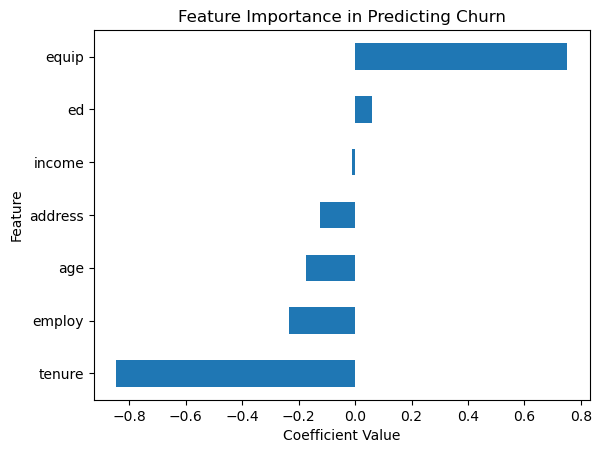

In [13]:
# Role of each input feature in the prediction of churn
coefficients = pd.Series(LR.coef_[0], index= churn_df.columns[:-1])
coefficients.sort_values().plot(kind='barh')
plt.title('Feature Importance in Predicting Churn')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()

## 📊 Performance Evaluation

Once the predictions have been generated, it is essential to evaluate the performance of the model in predicting the target variable.  
One widely used metric for probabilistic classifiers like **Logistic Regression** is **Log Loss**.

---

### 🔹 Log Loss

**Logarithmic Loss (Log Loss)**, also known as **Binary Cross-Entropy Loss**, measures the performance of a classification model where the prediction is a probability value between 0 and 1.

- A **lower Log Loss** indicates better model performance.  
- A **perfect model** has a Log Loss of **0**.  
- For binary classification, a random guess typically yields a Log Loss of around **0.693**.

The formula for Log Loss is:

$$
\text{Log Loss} = - \frac{1}{N} \sum_{i=1}^{N} \Big[ y_i \cdot \log(\hat{p}_i) + (1-y_i) \cdot \log(1-\hat{p}_i) \Big]
$$

Where:  
- $N$ = total number of samples  
- $y_i \in \{0,1\}$
- $\hat{p}$ = predicted probability



In [16]:
# Compute log loss 
loss = log_loss(y_test, y_pred_proba)
print("Log Loss:", loss) 

Log Loss: 0.6257718410257235


## 📊 Model Evaluation Metrics

To evaluate the performance of the churn prediction model, we use several standard classification metrics. Each metric highlights a different aspect of model performance.

---

### 🔹 Accuracy
$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

- The proportion of correct predictions (both churn and non-churn) out of all predictions.  
- Easy to understand, but can be **misleading on imbalanced datasets** (e.g., if 80% of customers don’t churn, a model that always predicts “No Churn” would have 80% accuracy but be useless).

---

### 🔹 Precision
$$
\text{Precision} = \frac{TP}{TP + FP}
$$

- Of all customers the model predicted **churn**, how many actually churned.  
- High precision means **few false alarms** (low false positives).  
- Important when the cost of wrongly flagging a non-churner as churner is high.

---

### 🔹 Recall (Sensitivity / True Positive Rate)
$$
\text{Recall} = \frac{TP}{TP + FN}
$$

- Of all customers who **actually churned**, how many were correctly identified.  
- High recall means **few missed churners** (low false negatives).  
- Important when the cost of **missing a churner** is high (e.g., losing valuable customers).

---

### 🔹 F1-Score
$$
F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$

- Harmonic mean of Precision and Recall.  
- Provides a balanced score when both false positives and false negatives matter.  
- Especially useful on **imbalanced datasets** like churn prediction.

---

### 🔹 ROC-AUC (Receiver Operating Characteristic – Area Under Curve)
- Measures the model’s ability to **discriminate** between churn and non-churn across all classification thresholds.  
- Value ranges between **0.5 (random guessing)** and **1.0 (perfect model)**.  
- A higher ROC-AUC means the model is better at ranking churners above non-churners.

---

### 🔹 Confusion Matrix
A table that summarizes predictions:

|                | Predicted: No Churn | Predicted: Churn |
|----------------|----------------------|------------------|
| **Actual: No** | True Negative (TN)   | False Positive (FP) |
| **Actual: Yes**| False Negative (FN)  | True Positive (TP)  |

- Helps visualize how many customers are correctly/incorrectly classified.  


📊 Model Evaluation Summary

              precision    recall  f1-score   support

           0       0.69      1.00      0.82        25
           1       1.00      0.27      0.42        15

    accuracy                           0.72        40
   macro avg       0.85      0.63      0.62        40
weighted avg       0.81      0.72      0.67        40

Confusion Matrix:
 [[25  0]
 [11  4]]
ROC-AUC Score: 0.7013333333333334


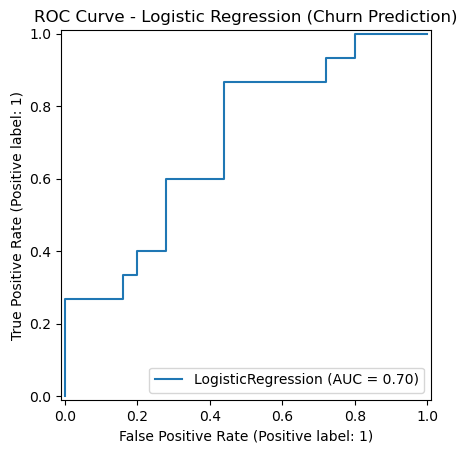

In [33]:
# Model Evaluation accuracy, precision, recall, f1-score, support and ROC-AUC

print("📊 Model Evaluation Summary\n")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba[:, 1]))
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# ROC curve directly from the estimator
RocCurveDisplay.from_estimator(LR, X_test, y_test)
plt.title("ROC Curve - Logistic Regression (Churn Prediction)")
plt.show()



## 📝 Conclusion

The Logistic Regression model for predicting customer churn provides some useful insights but also highlights areas for improvement:

- **Strengths:**
  - The model is **highly precise** when predicting churn (precision = 1.0), meaning customers flagged as likely to churn are indeed at risk.
  - It correctly identifies **all non-churners** (recall for class 0 = 1.0), avoiding unnecessary retention actions.
  - Feature analysis shows which factors (e.g., contract type, monthly charges, equipment services) influence churn probability, offering actionable business insights.

- **Weaknesses:**
  - **Low recall for churners** (recall for class 1 = 0.27) indicates that the model **misses most actual churners**, which limits its effectiveness for proactive retention campaigns.
  - Overall ROC-AUC = 0.70 suggests **moderate discriminative ability**; there is room for improvement in separating churners from non-churners.
  - Accuracy (0.72) is influenced by the class imbalance and does not fully reflect the model’s ability to predict churn.

- **Recommendations for Improvement:**
  1. Adjust the **classification threshold** to increase recall for churners.  
  2. Use **class weighting** or **resampling techniques** (SMOTE) to address class imbalance.  
  3. Explore more advanced models (Random Forest, XGBoost, or ensemble methods) to improve predictive performance.  
  4. Continue monitoring feature importance to guide business retention strategies.

**Conclusion:**  
While the current Logistic Regression model provides some reliable insights, its low recall for churners means it should **not be used alone for retention campaigns**. Enhancing the model through threshold tuning, handling class imbalance, and using more powerful algorithms will improve the ability to identify at-risk customers and enable more effective churn mitigation strategies.
